# ML from DFT data

In [1]:
import pickle
import os
import glob
import numpy as np
import pdb
import pandas as pd
from importlib.machinery import SourceFileLoader
import re
import sys
from tqdm.notebook import tqdm_notebook
from seaborn import heatmap
import seaborn as sns
from BopFoxFeaturizer.HelperFunctions import get_useful_features
from BopFoxFeaturizer.HelperFunctions import cleanfeaturenames
from BopFoxFeaturizer.HelperFunctions import histoff_realfeatures
import matplotlib.pyplot as plt
plt.style.use('default')
plt.rc('figure', figsize=(15,10))
plt.rc('legend',fontsize=24)
plt.rc('axes',labelsize=28)
plt.rc('xtick',labelsize=24)
plt.rc('ytick',labelsize=24)
from BopFoxFeaturizer.FeatureConcatenate import stackdata
from BopFoxFeaturizer.brief_summary_parser import StructSummaryParser
from BopFoxFeaturizer.Featurizer import Featurizer
from BopFoxFeaturizer import HelperFunctions as HF
#stackdata = SourceFileLoader('stackdata','BopFoxFeaturizer/FeatureConcatenate.py').load_module().stackdata
# Original DFT Data
%run SourceDevelopementVersion.py
# which loads Featu
import glob

# Parameters 

In [2]:
CASE = 'INITIAL'  #, 'INITIAL', RELAXED
MODEL = 'CANONICAL' #, 'ORTHOGONAL', 'CANONICAL'
CUT_OFF = 'TABLECUTOFF' # 'TABLECUTOFF', 'HISTCUTOFF'
E_MODE = 'WENERGY'  # test_score, train_score, err
C_RITERION = ''
SEARCH_MODE = ''

# Helpeer Functions 

In [3]:
from Tools import CaseNamer

In [4]:
FileNames = CaseNamer(CASE, MODEL,CUTOFF=CUT_OFF, EMODE=E_MODE,CRITERION=C_RITERION,SEARCHMODE = SEARCH_MODE)

In [5]:
from Tools import Plotting

# Load Features

## Load briefsummary and its features

In [6]:
BS = StructSummaryParser().BriefSummary
Features = Featurizer(BS)

## Load the BOP for the selected case

In [7]:
BOPCOEF_FILE = 'CRCOW_{}_NSC_{}_{}_{}.pkl'.format(CASE,MODEL,CUT_OFF,E_MODE)
BopfoxFeatures = pd.read_pickle(BOPCOEF_FILE)
#BopfoxFeatures.drop(columns=['NSC_U_bond_atom_list'], inplace=True)
#BopfoxFeatures.drop(columns=['NSC_U_bind'], inplace=True)

## clean features: reduntandly convert all features to float and mean across sites

In [8]:
BopfoxFeatures.dropna(how='any',inplace=True)
M = BopfoxFeatures['NSC_moments'].map(lambda M: np.array(M).mean(axis=0))
S = BopfoxFeatures['NSC_SIGMA'].map(lambda M: np.array(M).mean(axis=0))
Binf=BopfoxFeatures['NSC_Binf'].map(lambda s: [float(si) for si in s]).map(np.mean)
Ainf=BopfoxFeatures['NSC_Ainf'].map(lambda s: [float(si) for si in s]).map(np.mean)
AN = BopfoxFeatures['NSC_an'].map(lambda M: np.array(M).mean(axis=0))
BN = BopfoxFeatures['NSC_bn'].map(lambda M: np.array(M).mean(axis=0))
Mag = Features.MagFeature[BopfoxFeatures.index]
BOP_atom_average = pd.concat([BopfoxFeatures['NSC_U_bind'], M, S, AN, BN, Ainf, Binf, Mag], axis=1)
# Feature Transformation to concatenation
BOP, names = stackdata(BOP_atom_average, BOP_atom_average.columns.values)
BOP = pd.DataFrame(data=BOP, columns=names, index = BOP_atom_average.index)

## define the column names by type of feature

In [9]:
allcolumns = BOP.columns

In [10]:
columns_Mag =BOP.columns[BOP.columns.str.contains('MagConfig')]
columns_U =BOP.columns[BOP.columns.str.contains('U_bind')]
columns_bn = BOP.columns[BOP.columns.str.contains('bn')]
columns_sigma =BOP.columns[BOP.columns.str.contains('SIGMA')] 
columns_moments = BOP.columns[BOP.columns.str.contains('moment')]
columns_an = BOP.columns[BOP.columns.str.contains('an')]

In [11]:
feature_titles = pd.Series(
    HF.cleanfeaturenames([ s.replace('NSC_','').replace('MagConfig_0','MagConfig').replace('bind_0','bind') for s in allcolumns ]), index=allcolumns
)

In [12]:
real_feature = HF.get_useful_features(BOP, allcolumns)

In [13]:
def colsgroup(kind):
    return [ f for f in real_feature if kind in f] 

In [14]:
useful = {f: colsgroup(f) for f in ['an','bn','moment','SIGMA', 'U_bind','MagConfig']}

# Targets

$ \Delta E_F  = \dfrac{1}{N_{atoms}} \left( E_{Total} - \sum _{i} N_i E_i \right) $

In [15]:
groundstates=Features.get_ground_states_energies()
BS['EF'] = Features.get_formation_energy(ground_states_dic=groundstates)
BS = BS.dropna()
DATA = BOP.copy()
DATA[['B0','V0','EF','E0']]=BS[['B0','V0','EF','E0']]

## Distribution of targets

### $E_{F}$

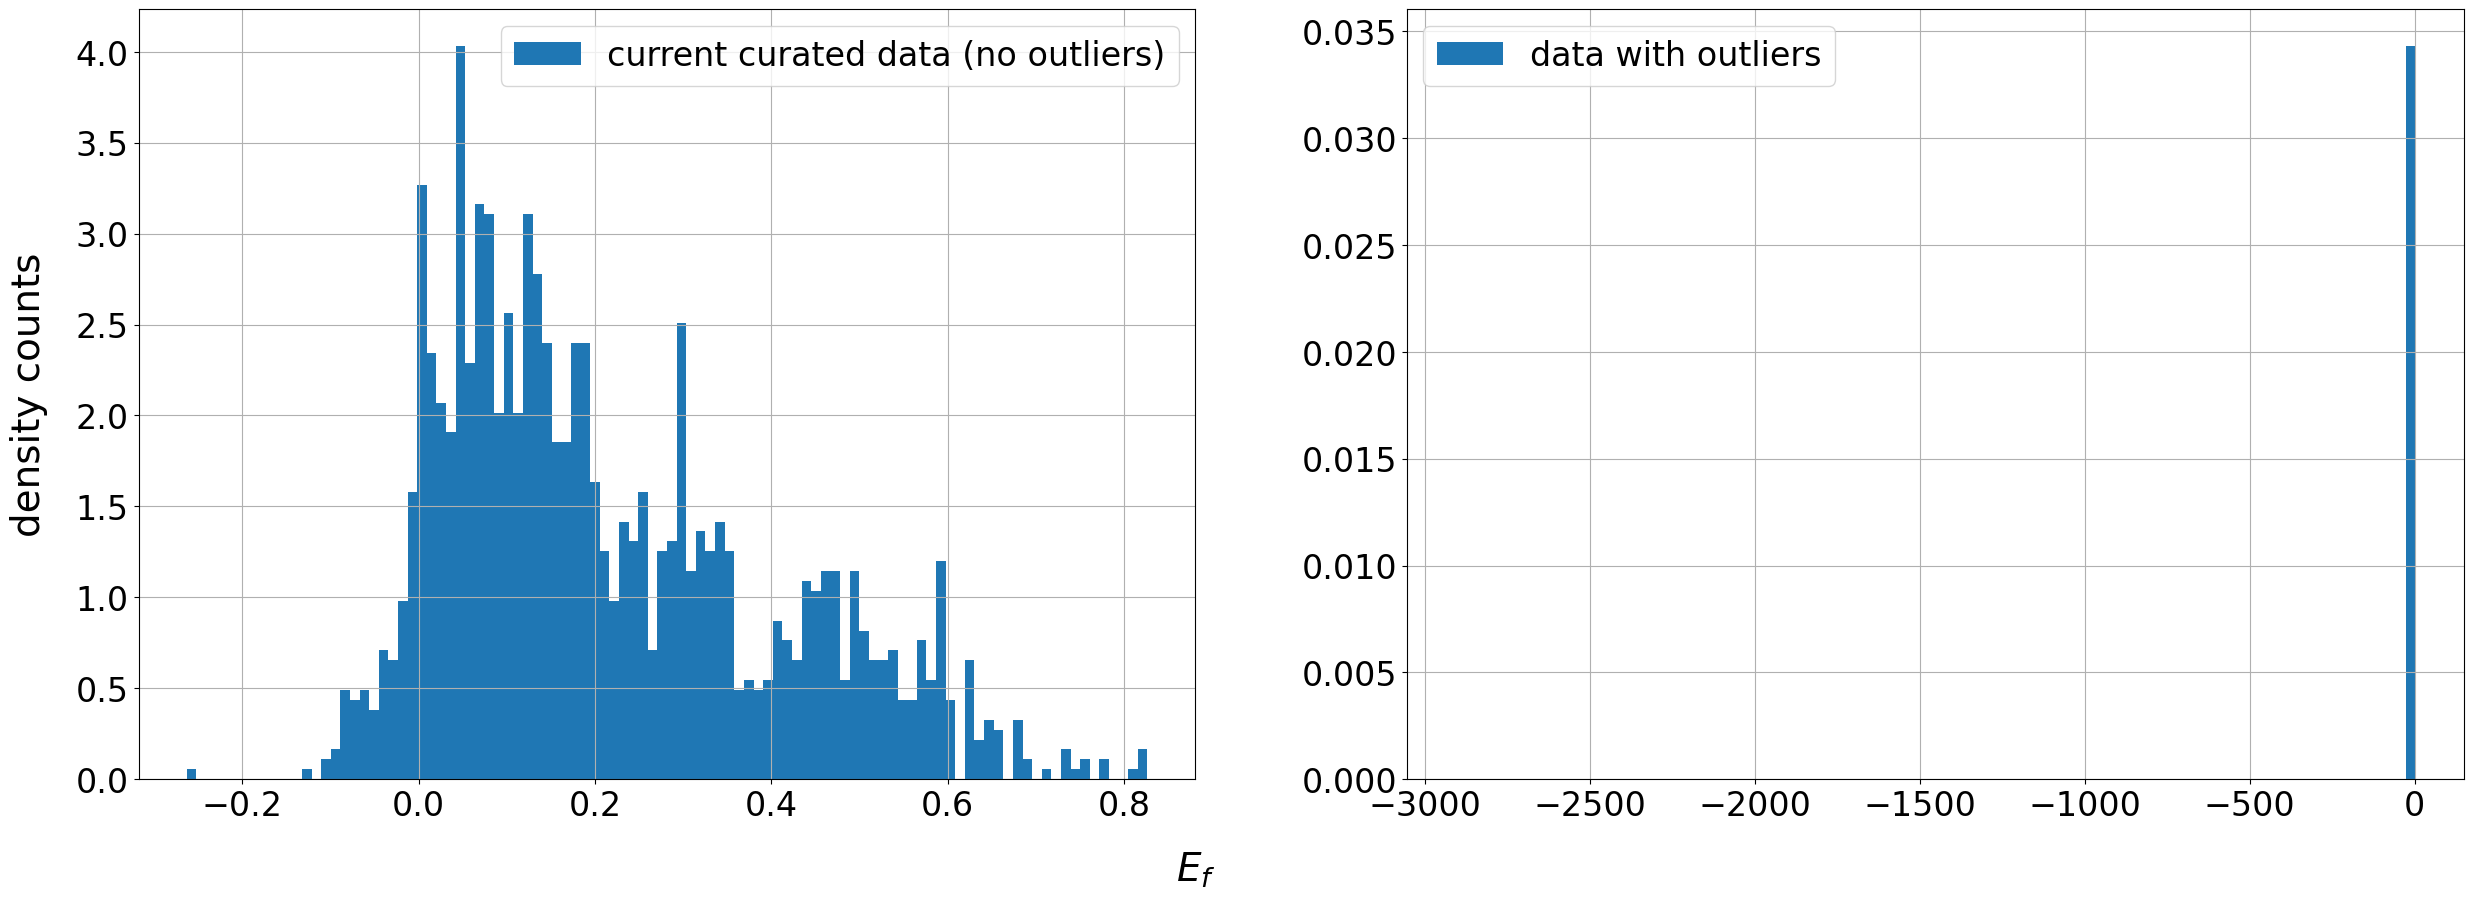

In [16]:
fig = Plotting.with_and_without_outliers(DATA['EF'],low=-1, hig=2.0)

In [17]:
Out_In_First = DATA[~((DATA['EF']>-1) & (DATA['EF']<2))]

In [18]:
Out_In_First

,NSC_U_bind_0,NSC_moments_0,NSC_moments_1,NSC_moments_2,NSC_moments_3,NSC_moments_4,NSC_moments_5,NSC_moments_6,NSC_moments_7,NSC_moments_8,...,NSC_bn_18,NSC_bn_19,NSC_bn_20,NSC_Ainf_0,NSC_Binf_0,MagConfig_0,B0,V0,EF,E0
index,,,,,,,,,,,,,,,,,,,,,
Cr_pv11W_sv2.mu-AAAAB.NM,-74.122991,0.0,1.779759,-0.575332,6.427369,-4.502642,31.837080,-34.624192,194.691246,-288.881477,...,0.0,0.0,0.0,-0.290871,1.505827,0.0,1013.263491,797.261714,-2908.966186,-2918.897693
Co_pv8W_sv4.C14-BAA.FM,-80.856962,0.0,2.496405,-0.957307,12.508827,-10.171457,85.054667,-109.894300,715.144333,-1293.729000,...,0.0,0.0,0.0,-0.369630,1.757653,2.0,-3.039032,347.454241,3.087797,-5.877353
Cr_pv10Co_pv4W_sv16.sigma-ABCCA.FM,-183.428823,0.0,1.934360,-0.644754,6.523645,-4.441069,27.740273,-27.454160,136.842400,-170.988120,...,0.0,0.0,0.0,-0.175496,1.385139,2.0,-0.754852,780.349477,2.390903,-8.574481


In [19]:
DATA = DATA[(DATA['EF'] > -1) & (DATA['EF']< 2)]

### $E_0$

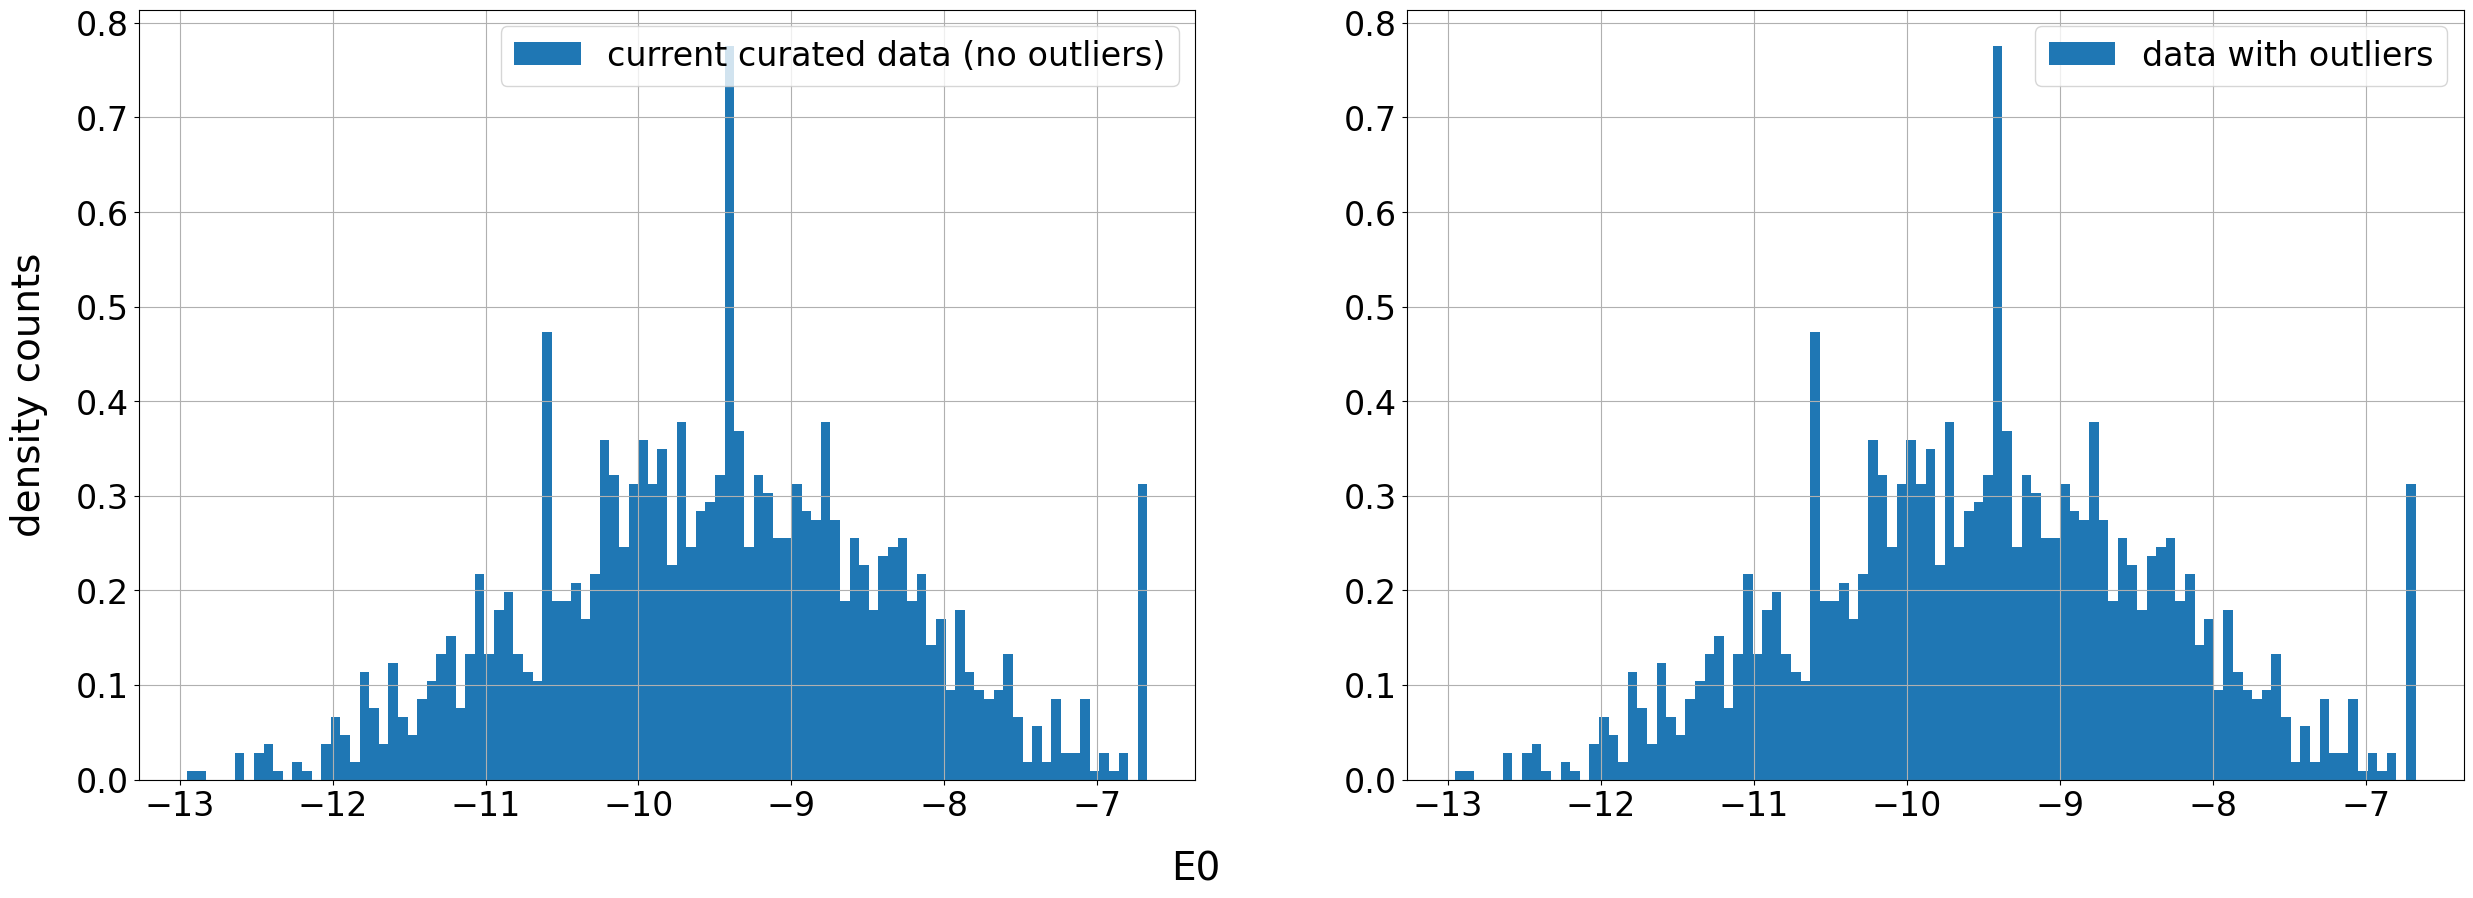

In [20]:
fige0 = Plotting.with_and_without_outliers(DATA['E0'],low=-100, hig=10, title='E0')

In [21]:
DATA = DATA[(DATA['E0']>-100) & (DATA['E0']<10)]

In [22]:
DATA.shape

(1684, 90)

### $E_0$ vs $\Delta E_{F}$

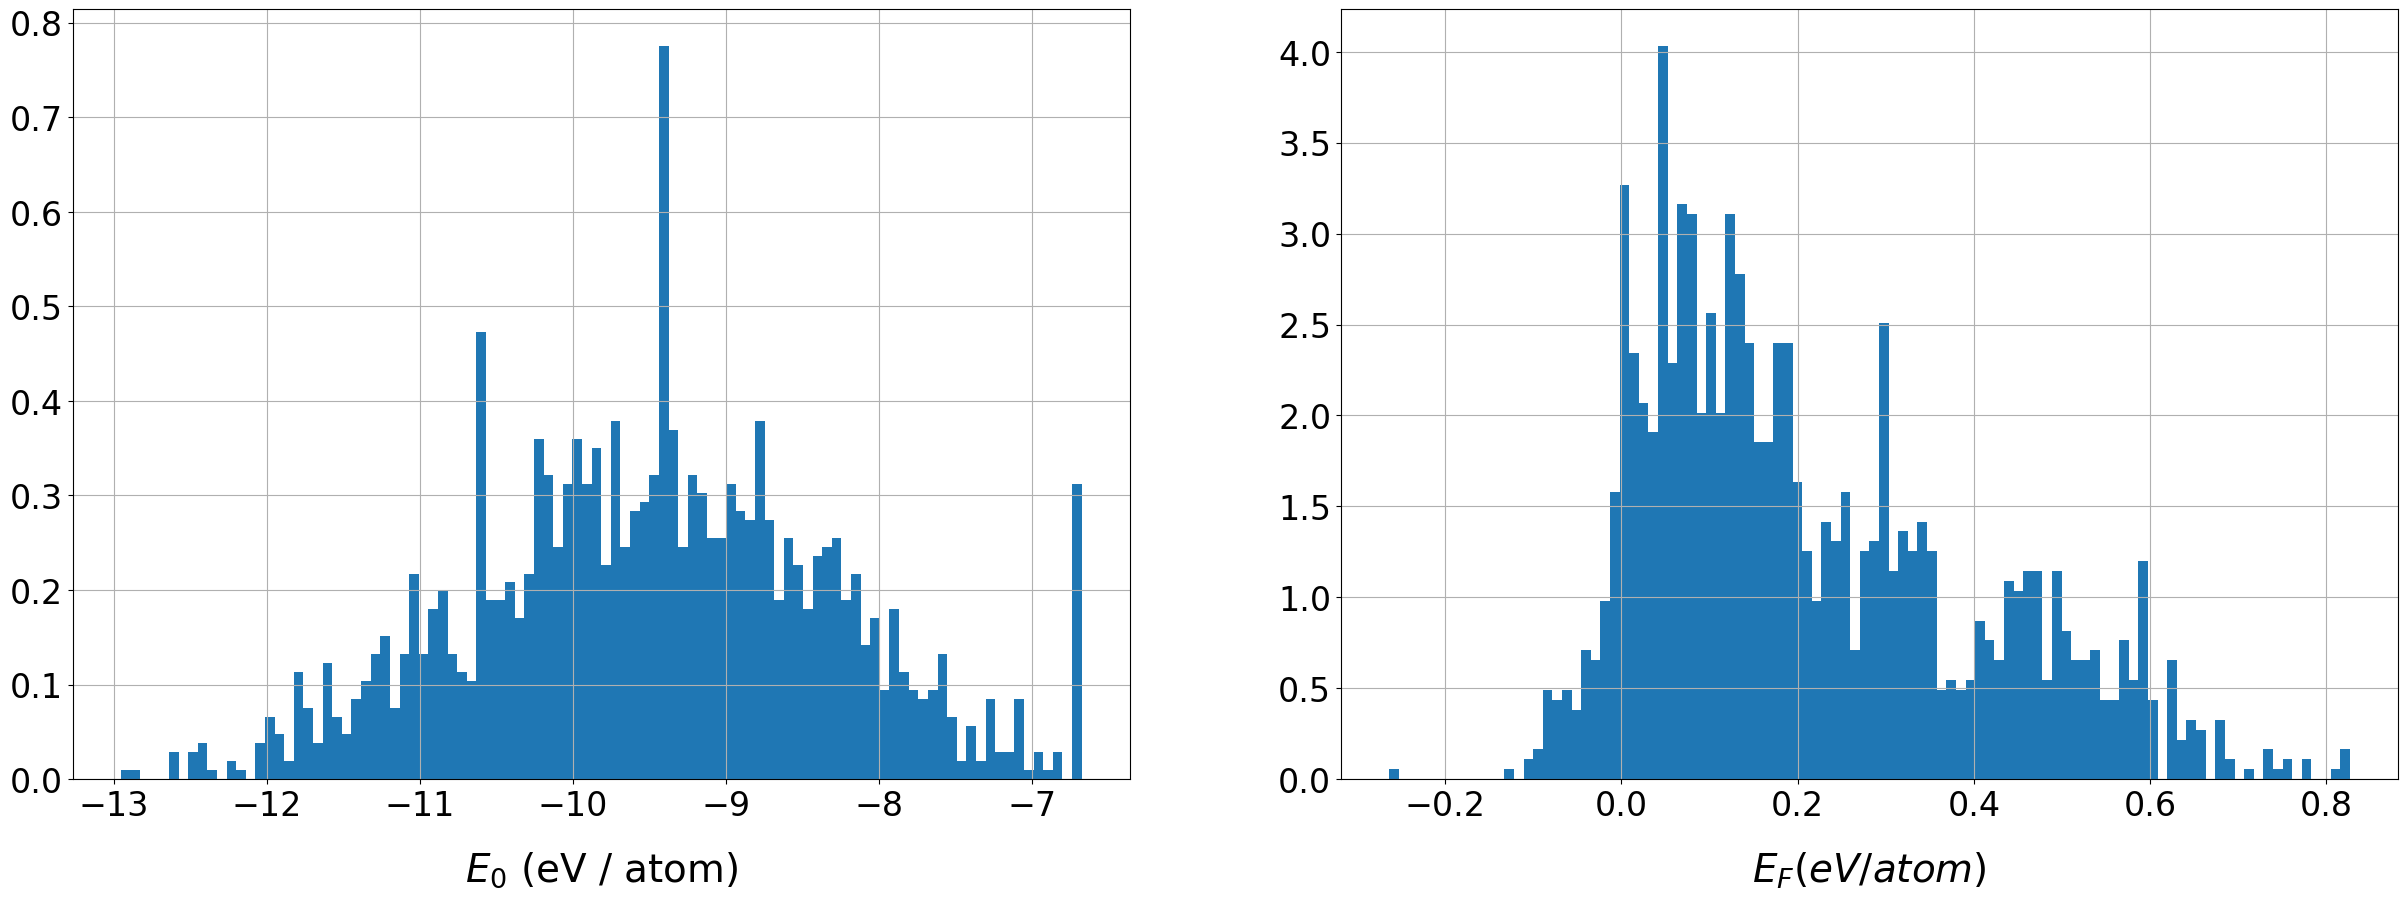

In [23]:
figcomp = Plotting.compare_features(DATA['EF'],'$E_{F} (eV / atom)$', DATA['E0'],'$E_{0}$ (eV / atom)')

## B0

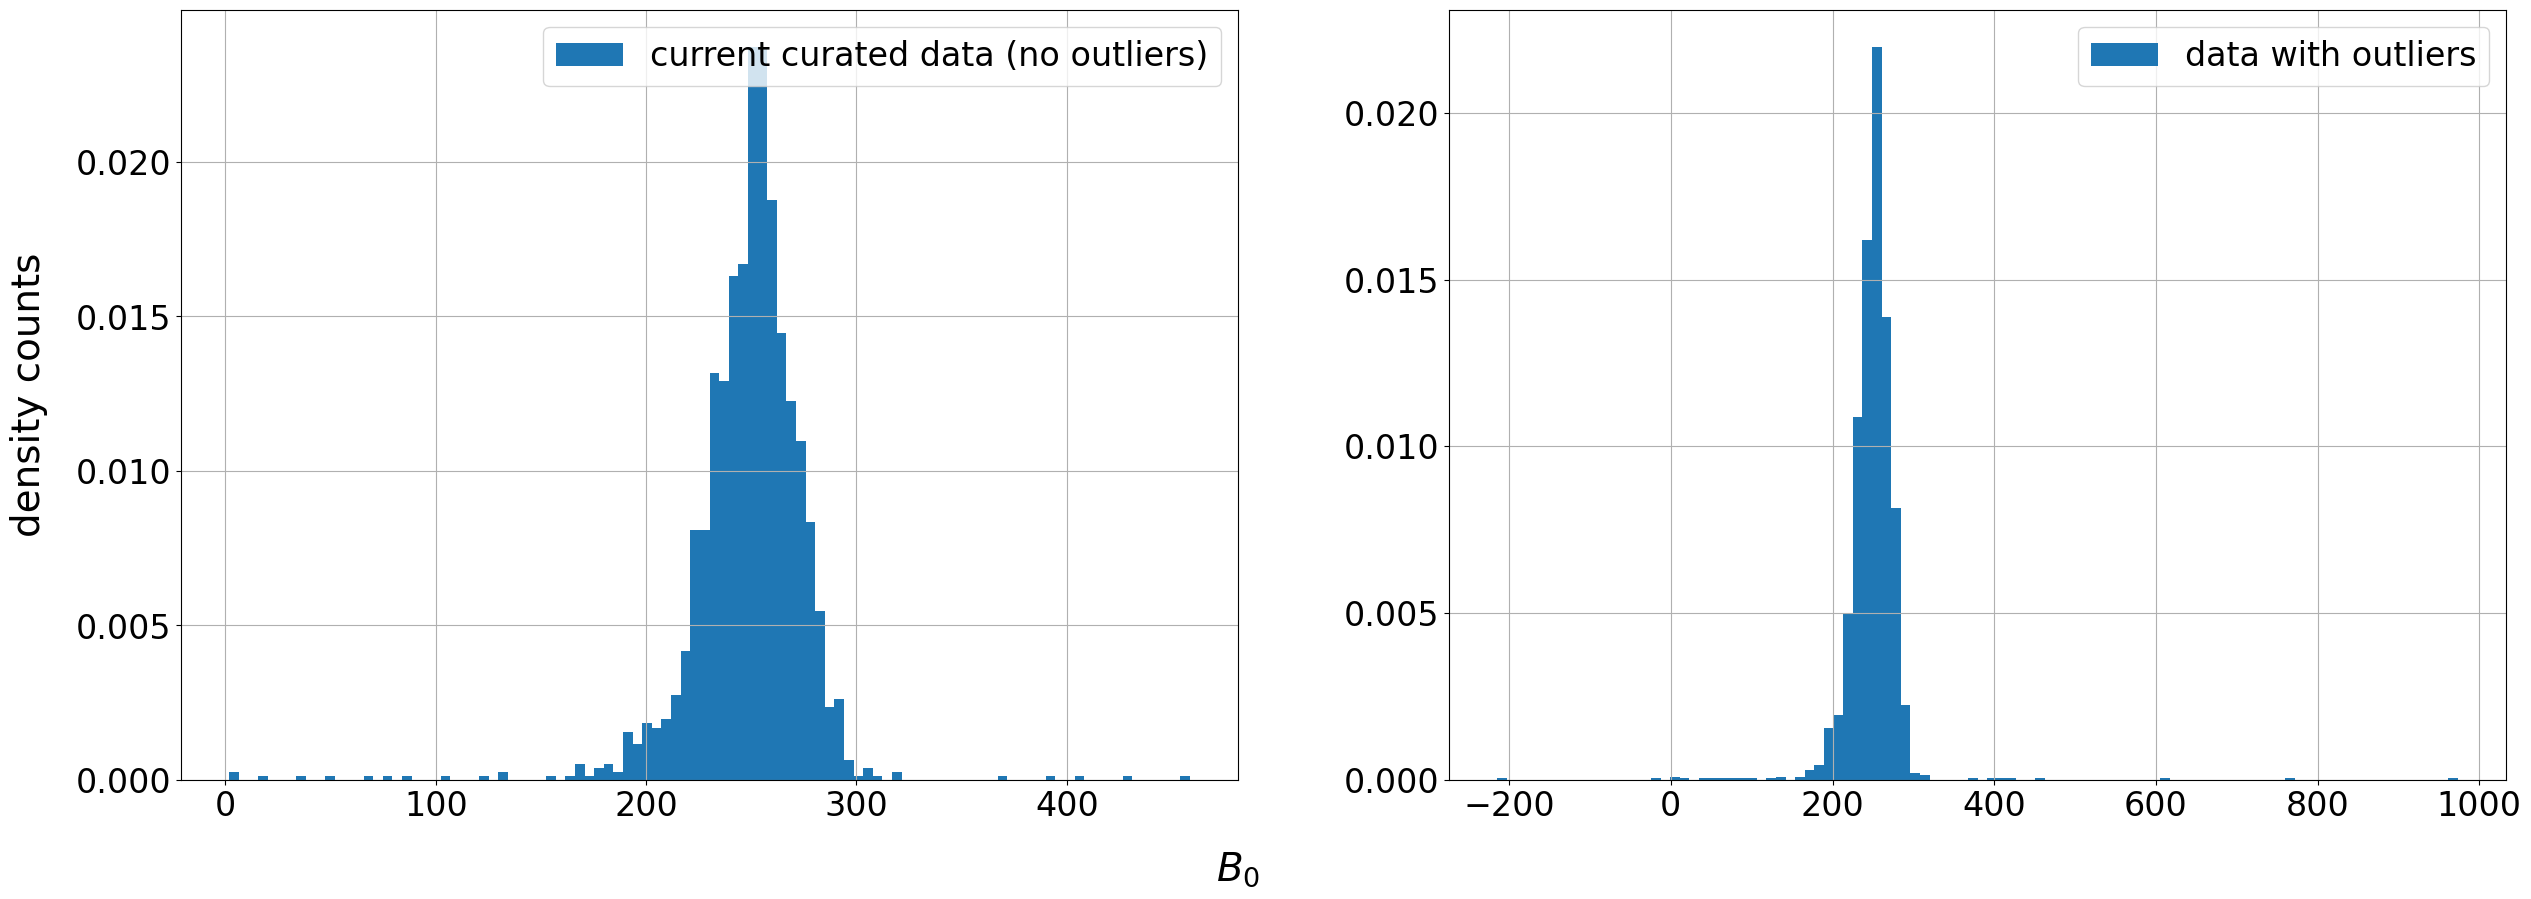

In [24]:
figB0 = Plotting.with_and_without_outliers(DATA['B0'], low=0, hig=500,title='$B_0$')

In [25]:
DATA[(DATA['B0'])<0 | (DATA['B0']>500)]

,NSC_U_bind_0,NSC_moments_0,NSC_moments_1,NSC_moments_2,NSC_moments_3,NSC_moments_4,NSC_moments_5,NSC_moments_6,NSC_moments_7,NSC_moments_8,...,NSC_bn_18,NSC_bn_19,NSC_bn_20,NSC_Ainf_0,NSC_Binf_0,MagConfig_0,B0,V0,EF,E0
index,,,,,,,,,,,,,,,,,,,,,
Cr_pv1Co_pv28.chi-ABBB.FM,-189.328553,0.0,2.212484,-0.737217,8.411234,-6.099602,38.993897,-43.659024,204.756862,-304.666483,...,0.0,0.0,0.0,-0.252484,1.316658,2.0,-19.618559,1.958360,0.217218,-6.836854
Cr_pv18Co_pv6.C36-AAABA.FM,-141.318850,0.0,1.909656,-0.651702,7.508902,-5.425544,41.216815,-48.025133,285.409500,-476.560667,...,0.0,0.0,0.0,-0.382666,1.564857,2.0,-214.604035,17.026433,0.175928,-8.603332


In [26]:
DATA = DATA[(DATA['B0'])>0 & (DATA['B0']<500)]

In [27]:
DATA.shape

(1682, 90)

## Drop Nans !

In [28]:
DATA.dropna(how='any', axis=0,inplace=True)

# Histograms of features

Are there more outliers ?

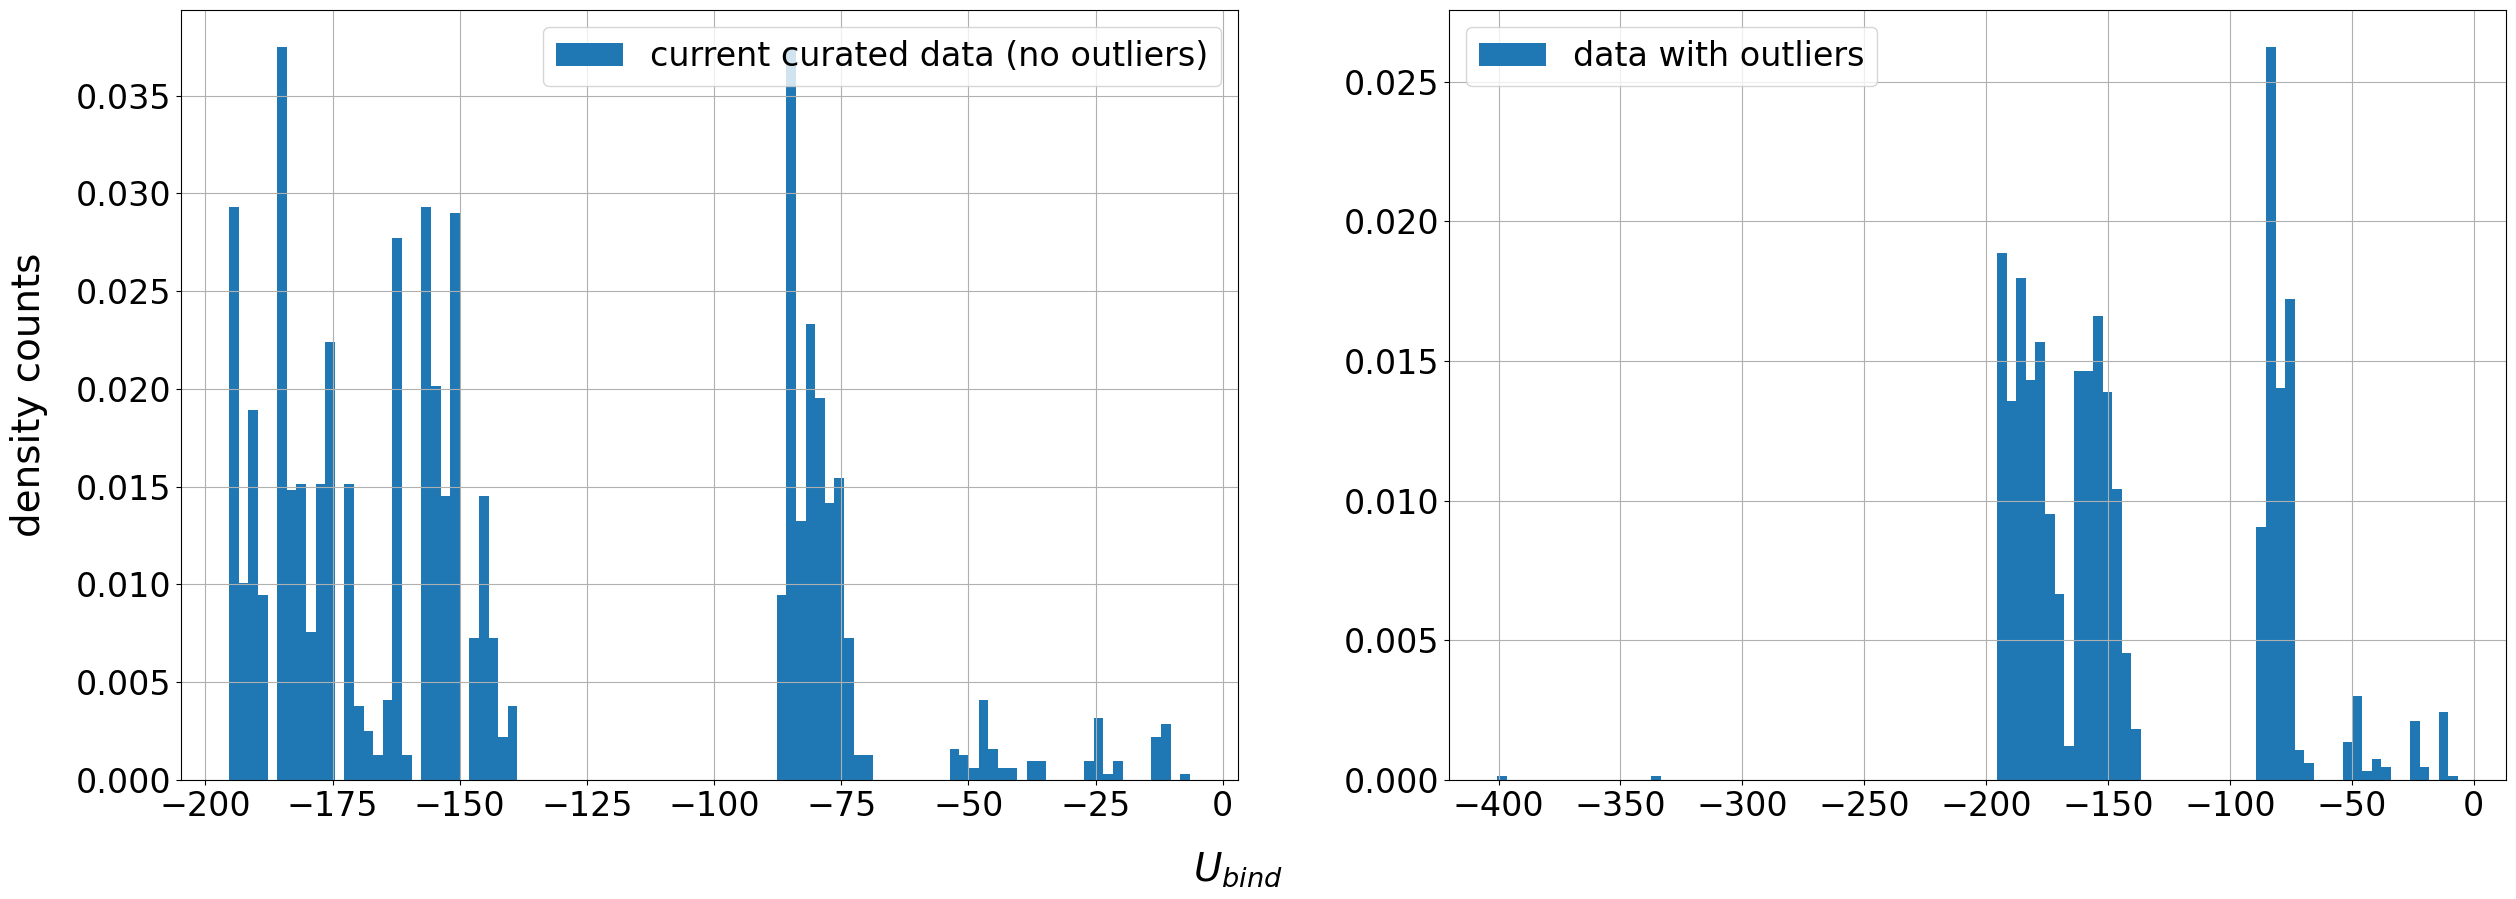

In [29]:
figUbind = Plotting.with_and_without_outliers(DATA['NSC_U_bind_0'], low=-200, hig=0,title=feature_titles[columns_U].values[0])

In [30]:
DATA[(DATA['NSC_U_bind_0'])<-200 ]

,NSC_U_bind_0,NSC_moments_0,NSC_moments_1,NSC_moments_2,NSC_moments_3,NSC_moments_4,NSC_moments_5,NSC_moments_6,NSC_moments_7,NSC_moments_8,...,NSC_bn_18,NSC_bn_19,NSC_bn_20,NSC_Ainf_0,NSC_Binf_0,MagConfig_0,B0,V0,EF,E0
index,,,,,,,,,,,,,,,,,,,,,
W_sv53.R.NM,-400.504590,0.0,3.205826,-0.553611,21.799976,-5.830008,196.283966,-48.704141,2050.179434,-302.300921,...,0.0,0.0,0.0,0.053744,1.897987,0.0,283.751697,16.733067,0.349466,-12.604124
Cr_pv53.R.NM,-333.878749,0.0,2.228423,-0.320841,10.533441,-2.348617,65.925979,-13.638509,478.653468,-58.843408,...,0.0,0.0,0.0,0.044808,1.582420,0.0,241.165683,11.917624,0.111057,-9.270980


In [31]:
DATA.shape

(1682, 90)

In [49]:
Plotting = SourceFileLoader('Plotting', 'Tools.py').load_module().Plotting

In [50]:
np.ceil(len(useful['an'])/5).astype(int)

2

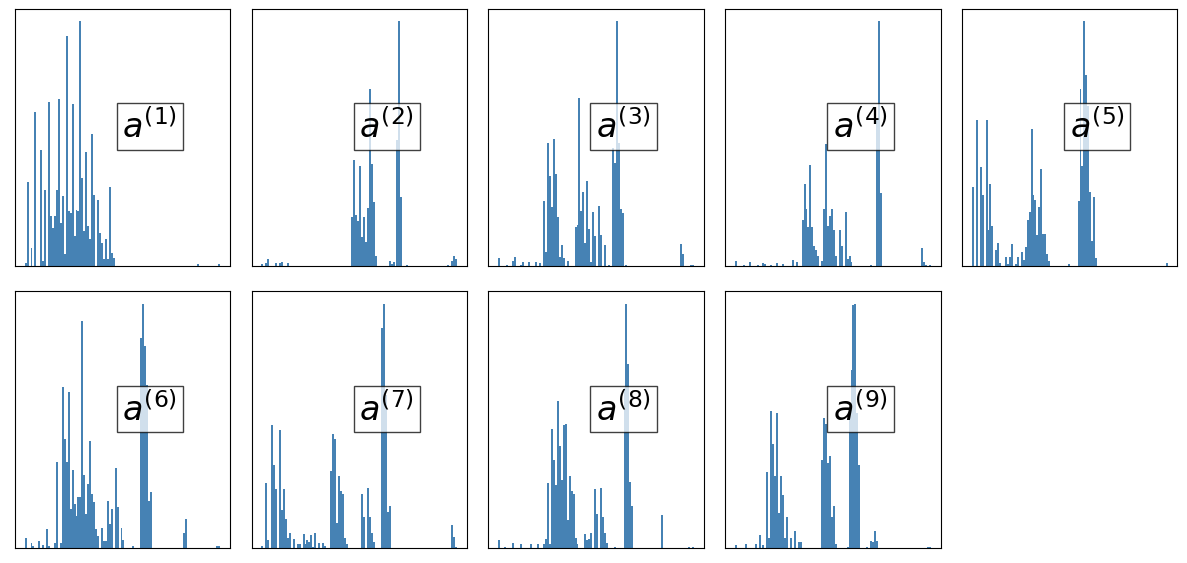

In [51]:
figure = Plotting.histoff_realfeatures(DATA,useful['an'],feature_titles[useful['an']], figsize_=(15,7))
figure.savefig(FileNames.get_plot_filename('Histogram', 'an'))

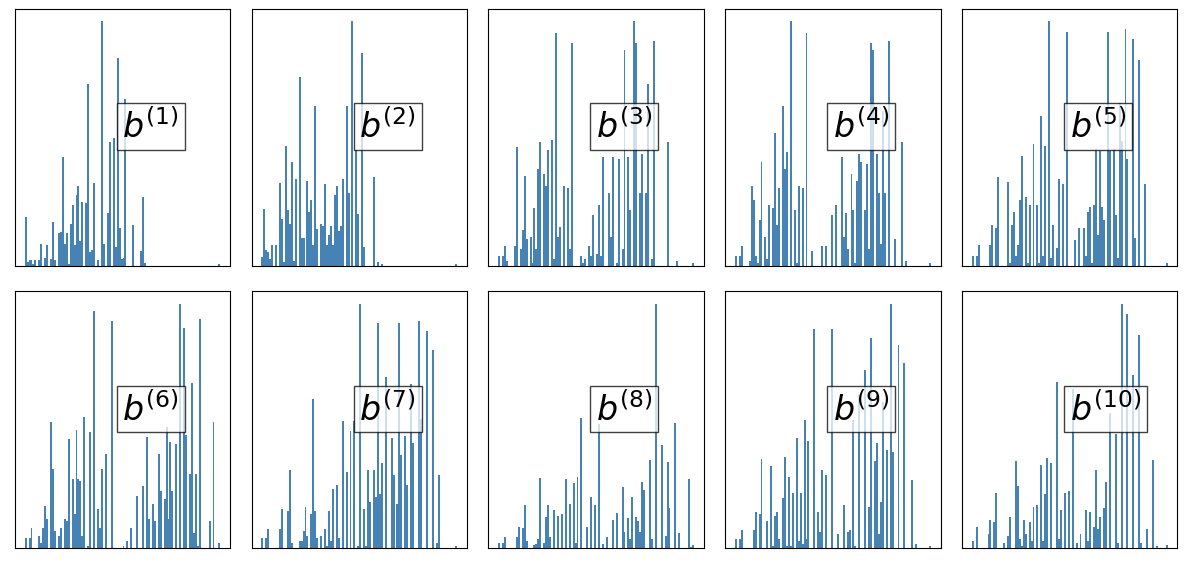

In [53]:
figure = Plotting.histoff_realfeatures(DATA,useful['bn'],feature_titles[useful['bn']],figsize_=(15,7))
figure.savefig(FileNames.get_plot_filename('Histogram','bn'))

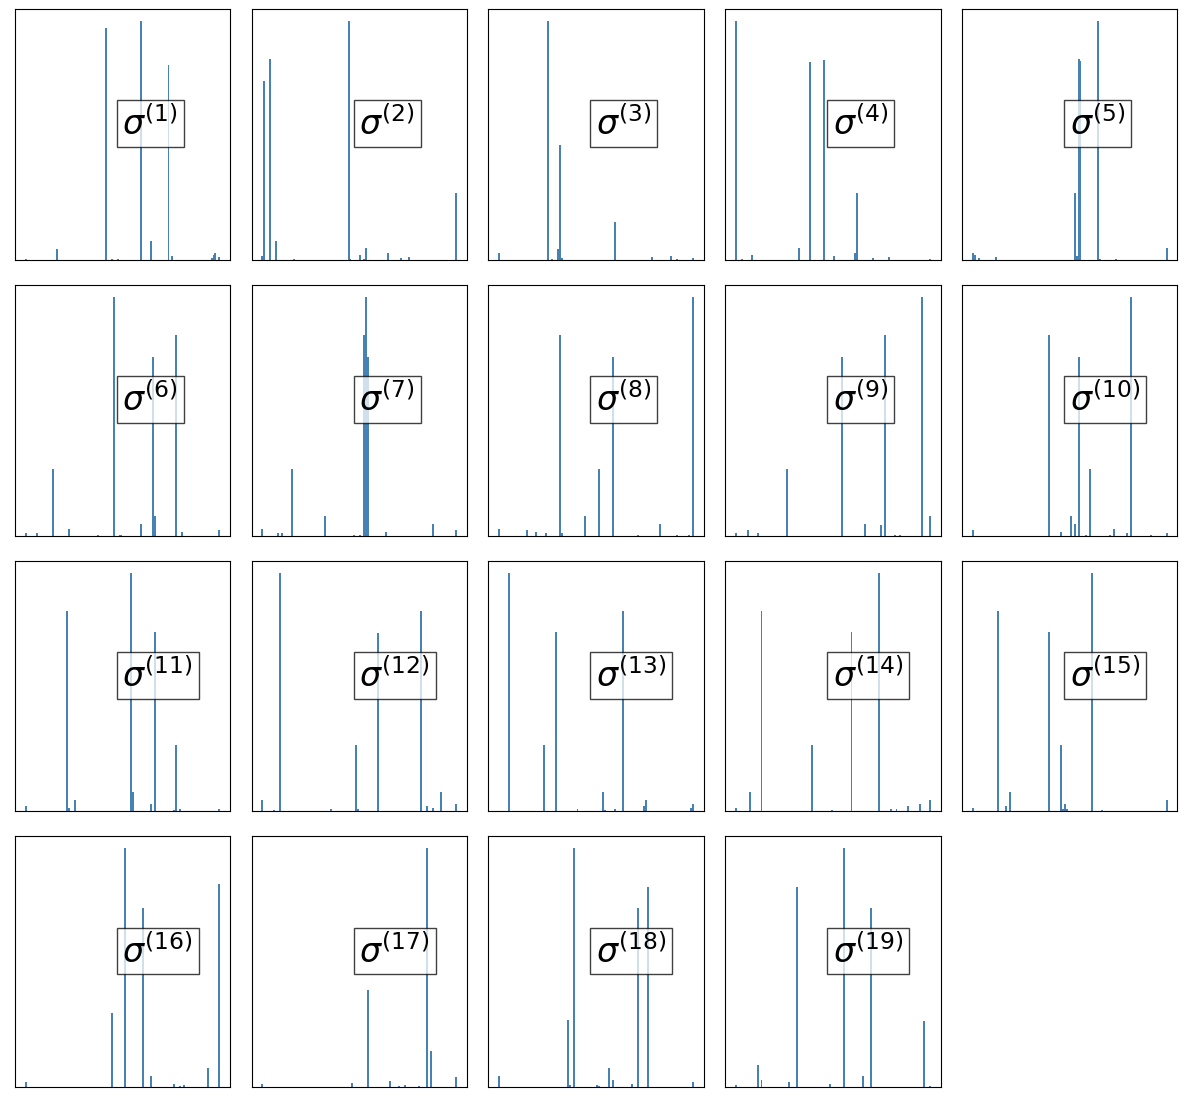

In [54]:
figure = HF.histoff_realfeatures(DATA,useful['SIGMA'],feature_titles[useful['SIGMA']],figsize_=(15,14))
figure.savefig(FileNames.get_plot_filename('Histogram','sigmas'))

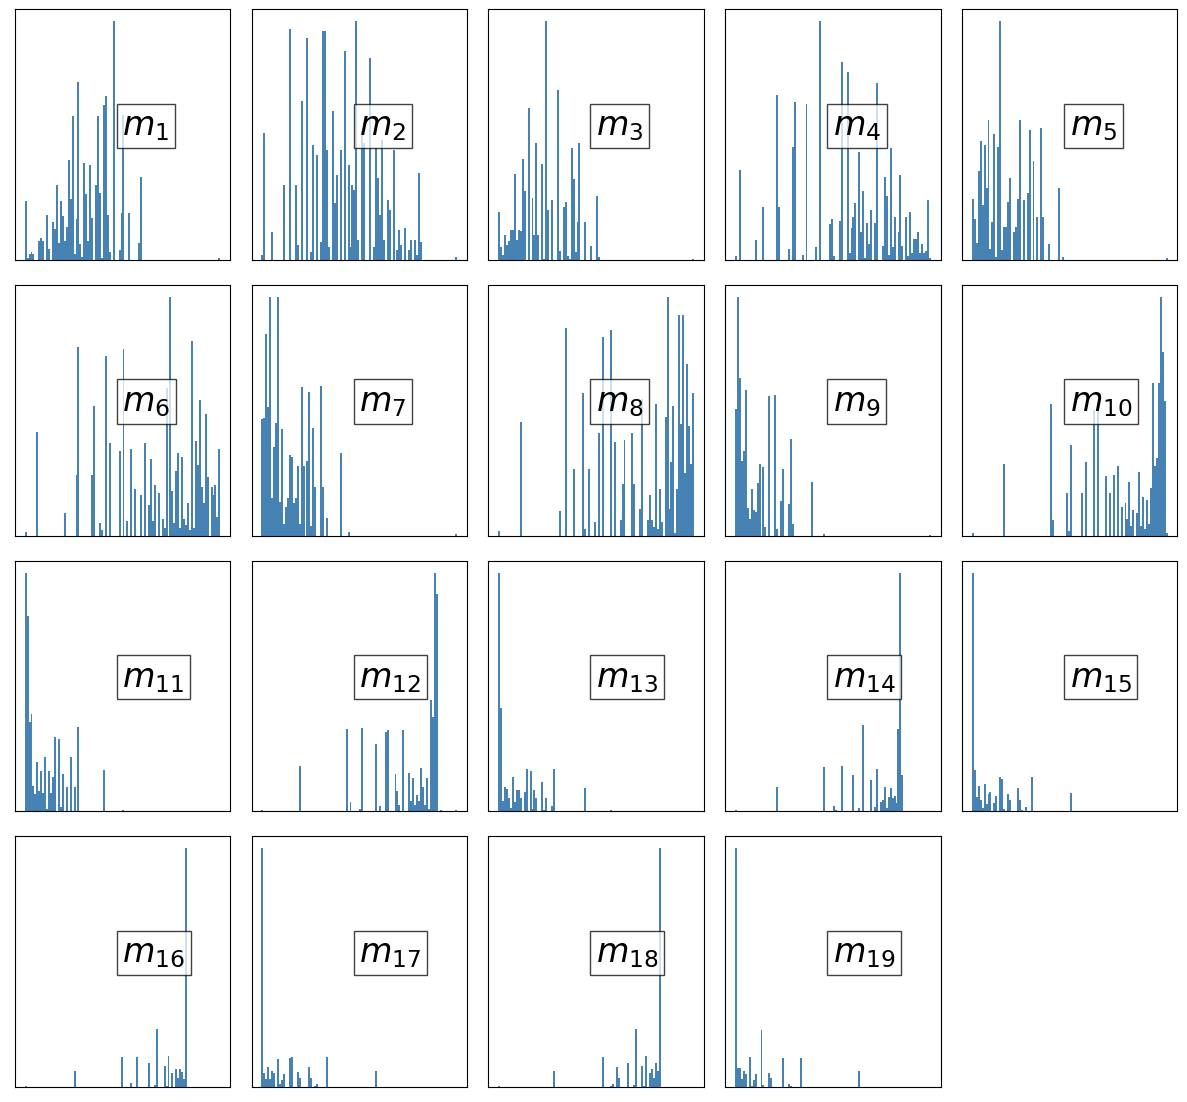

In [55]:
figure = HF.histoff_realfeatures(DATA,useful['moment'],feature_titles[useful['moment']],figsize_=(15,14))
figure.savefig(FileNames.get_plot_filename('Histogram','moments'))

# all features in the same Range

In [119]:
from sklearn.preprocessing import StandardScaler, MinMaxScaler

In [120]:
SC = MinMaxScaler()
BOPSC = pd.DataFrame(SC.fit_transform(BOP[real_feature]), columns=real_feature, index=BOP.index)

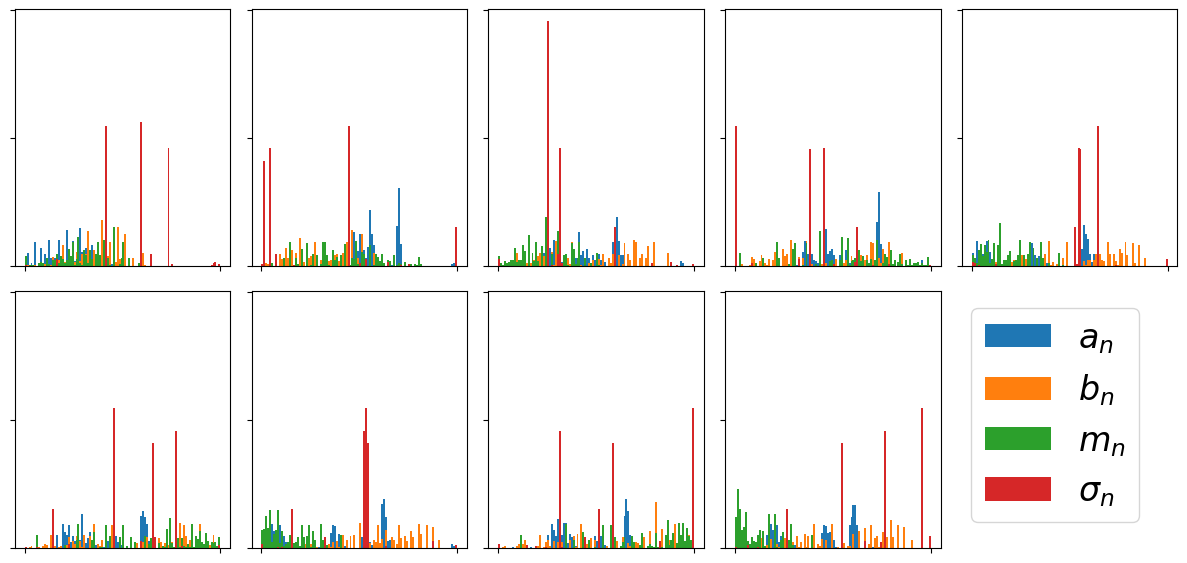

In [136]:
nrows = np.ceil(len(useful['an'])/5).astype(int)
fig, ax = plt.subplots(nrows, 5, figsize=(15,7),sharex=True,sharey=True)
for n, (thean, thebn, themn, thesn) in enumerate(zip(useful['an'], useful['bn'], useful['moment'], useful['SIGMA'])):
    thisrow = np.floor(n/5).astype(int)
    thiscol = n%5
    histan = ax[thisrow, thiscol].hist(BOPSC[thean], bins=100, label=feature_titles[thean])
    histbn = ax[thisrow, thiscol].hist(BOPSC[thebn], bins=100, label=feature_titles[thebn])
    histmu = ax[thisrow, thiscol].hist(BOPSC[themn], bins=100, label=feature_titles[themn])
    histsig = ax[thisrow, thiscol].hist(BOPSC[thesn], bins=100, label=feature_titles[thesn])
ax[-1,-1].set_xticklabels([])
ax[-1,-1].set_yticklabels([])
ax[-1,-1].remove()
h,l  = ax[0,0].get_legend_handles_labels()
ax[-1,-2].legend(h,['$a_{n}$','$b_{n}$','$m_{n}$', '$\sigma_{n}$'],  bbox_to_anchor = (2, 1))
fig.subplots_adjust(hspace=0.1, wspace=0.1)
fig.savefig(FileNames.get_plot_filename('CompareStandardDistributions','an_bn_mn_sigma')) 

# Classification and weighting

Text(0, 0.5, '')

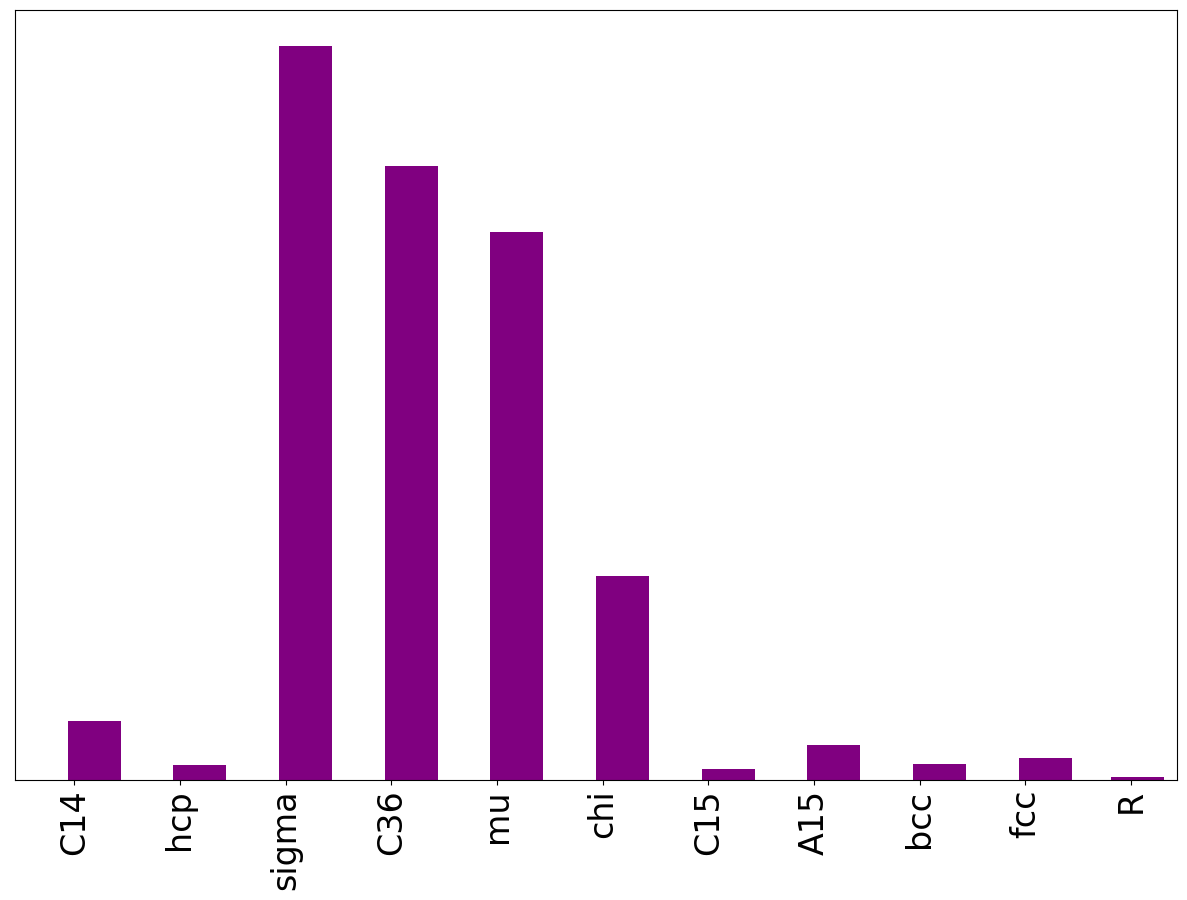

In [81]:
from BopFoxFeaturizer.struct_db import struct_db
#struct_db = SourceFileLoader('struct_db','BopFoxFeaturizer/struct_db.py').load_module().struct_db
strucdic = struct_db().strucstrings

Target_Class = pd.Series(
    DATA.index.str.split('.').map(lambda l: l[1]).map(lambda s: s.split('-')[0]),
    index=DATA.index
)
Target_Class[Target_Class.map(lambda s: s in strucdic['list.hcp'])]='hcp'
Target_Class[Target_Class.map(lambda s: s in strucdic['list.fcc'])]='fcc'
Target_Class[Target_Class.map(lambda s: s in strucdic['list.bcc'])]='bcc'
Target_Class[Features.Struc == 'hcp'] = 'hcp'
Target_Class[Features.Struc == 'bcc'] = 'bcc'
Target_Class[Features.Struc == 'fcc'] = 'fcc'
Target_Class[Features.Struc.str.contains('SQS-fcc')] = 'fcc'
Target_Class[Features.Struc.str.contains('SQS-L12')] = 'fcc'
Target_Class[Features.Struc.str.contains('sigma_')] = 'sigma'

Target_Class[    
    Target_Class.str.contains('Al42W') |\
    Target_Class.str.contains('Al9Co2') |\
    Target_Class.str.contains('Al5W') |\
    Target_Class.str.contains('Al12W') |\
    Target_Class.str.contains('Al4W') |\
    Target_Class.str.contains('Al5Co2')
] = 'others'

plt.hist(Target_Class, bins=80, density = True, width=0.5, align='left', color = 'purple')
plt.xticks(rotation=90); yticks = plt.yticks([])
plt.ylabel('')

#  Inspection among features

to compare between different features, first I have to reduce to standard ranges because the scale is too different. 